# Diffusion Models for Generative AI

Diffusion models are a class of generative models that create new data by reversing a process that gradually adds noise. They operate in two main phases:

- **Forward Process (Diffusion):** Noise is incrementally added to the original data over $T$ steps, transforming it into pure noise.
- **Model Training:** The model learns to predict the noise added at each step, enabling it to understand how to reverse the process.
- **Backward Process (Denoising):** Starting from random noise, the model iteratively removes noise over $T$ steps, reconstructing a new, realistic sample.

This approach allows diffusion models to generate new high-quality images from a image dataset by simulating the process of denoising.

## Imports

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import mnist

In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

mnist_train = mnist.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = mnist.MNIST(root='./data', train=False, download=True, transform=transform)

### Forward Process - Noising

Let $x_0$ be the image at t=0, and $x_t$ be the data at timestep $t$ after adding noise. The forward process is defined as:

$$ x_{n+1} = r \cdot x_n \cdot (1 - x_n) $$

where $r$ is a parameter (typically $3.5 < r < 4$ for chaotic behavior).

<!-- The cumulative process from $x_0$ to $x_t$:

$$
q(x_t | x_0) = N(x_t; \sqrt{\bar{\alpha}_t} x_0, \quad (1 - \bar{\alpha}_t) \mathbf{I})
$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

#### Algorithm

1. **Initialize** $x_0$ as the original data sample.
2. **For** $t = 1$ to $T$:
    - Sample noise $\epsilon_t \sim N(0, \mathbf{I})$
    - Compute $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon_t$
3. **Return** $x_T$ as the fully noised data. -->

This process gradually transforms the original data into pure noise over $T$ steps.

In [9]:
def Noising(images, T=30, r=3.9):
    batch_size = images.size(0)
    t = torch.randint(1, T+1, (batch_size,), device=images.device)
    x_t = images.clone()
    noise = torch.ones_like(images)
    for step in range(T):
        noise = r * noise * (1 - noise)
        x_t = images + noise
    return x_t, noise, t

### Deep Learning Model ###
A simple CNN based model to run over-the image reduse the dimensions and atlast give an output $\epsilon_t$.\
$\epsilon_t$ is a prediction of the amount of error introduced. And, the model learns to predict $\epsilon_t$ better and better.

## U-NET Model Architecture

This model is inspired by the **U-Net architecture**, with additional **time embeddings** to condition the network on the diffusion step `t`.

---

### Key Components
- **DoubleConv**: Two consecutive `Conv2d + ReLU` layers, used as the basic building block.  
- **Down (Encoder path)**: `MaxPool2d` for downsampling, followed by `DoubleConv`. Captures hierarchical features.  
- **Up (Decoder path)**: `Upsample` to increase spatial resolution, concatenates encoder features via skip connections, then applies `DoubleConv` to preserve fine details.  
- **OutConv**: Final `1×1 convolution` to reduce channels to match output image size.  
- **Time Embedding (`time_mlp`)**: Small MLP that processes the diffusion step `t` into an embedding, conditioning the model on the current timestep.

---

### Forward Pass
1. Input image `x` goes through the encoder:  
   `inc → down1 → down2 → down3 → down4`  
2. Decoder reconstructs the image with skip connections:  
   `up1(x5, x4) → up2(x, x3) → up3(x, x2) → up4(x, x1)`  
3. Final output produced with `OutConv`.  
4. Diffusion step `t` is embedded via `time_mlp` and conditions the model during training.

---

### Model Usage
- **Input**: noisy image `x` and diffusion step `t`  
- **Output**: predicted denoised image (same shape as `x`)  

This design makes the model suitable for **denoising diffusion probabilistic models (DDPMs)** and other generative tasks.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class unetm(nn.Module):
    def __init__(self, img_channels=1, hidden_dim=64):
        super().__init__()
        self.inc = DoubleConv(img_channels, hidden_dim)
        self.down1 = Down(hidden_dim, hidden_dim * 2)
        self.down2 = Down(hidden_dim * 2, hidden_dim * 4)
        self.down3 = Down(hidden_dim * 4, hidden_dim * 8)
        self.down4 = Down(hidden_dim * 8, hidden_dim * 8)
        self.up1 = Up(hidden_dim * 16, hidden_dim * 4)
        self.up2 = Up(hidden_dim * 8, hidden_dim * 2)
        self.up3 = Up(hidden_dim * 4, hidden_dim)
        self.up4 = Up(hidden_dim * 2, hidden_dim)

        # shared encoder-decoder body
        self.shared_out = DoubleConv(hidden_dim, hidden_dim)

        # head for predicting noise (image-shaped)
        self.noise_head = nn.Conv2d(hidden_dim, img_channels, kernel_size=1)

        # head for predicting timestep (scalar per sample)
        self.time_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # B,C,1,1
            nn.Flatten(),              # B,C
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)   # predict t
        )

    def forward(self, x):
        # UNet backbone
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        features = self.shared_out(x)

        # heads
        pred_noise = self.noise_head(features)
        pred_t = self.time_head(features)

        return pred_t, pred_noise

In [11]:
@torch.no_grad()
def Denoising(model, r=3.7, a=0.1, device="cpu"):
    img_size = (1, 28, 28)
    # start from uniform noise
    x_t = torch.rand(1, *img_size, device=device)

    # predict noise ONCE
    T, pred_noise = model(x_t)

    # iterative reverse using the same noise estimate
    for t in reversed(range(1, T + 1)):
        # inverse logistic equation
        disc = 1 - 4 * x_t / r
        disc = torch.clamp(disc, min=0.0)
        sqrt_disc = torch.sqrt(disc)

        x_prev_candidate1 = 0.5 * (1 + sqrt_disc)
        x_prev_candidate2 = 0.5 * (1 - sqrt_disc)

        # heuristic: pick branch closer to prediction
        mean = torch.where(
            torch.abs(x_prev_candidate1 - pred_noise) <
            torch.abs(x_prev_candidate2 - pred_noise),
            x_prev_candidate1, x_prev_candidate2
        )

        # update with fixed noise correction
        pred_image = mean - a * pred_noise

    return pred_image


### Model Training
- Design a loss function to train for $\epsilon_t$.
- For simplicity MSELoss

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = unetm().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

T = 30
r = 3.9 # decay factor
batch_size = 128
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        noisy_images, noise = Noising(images, T, r)

        pred_image = Denoising(model, r=3.7, a=0.1, device="cpu")

        loss = criterion(pred_image, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), 'diffusion_unet_model.pth')
print("Model weights saved to diffusion_unet_model.pth")

TypeError: randint() received an invalid combination of arguments - got (int, float, tuple, device=torch.device), but expected one of:
 * (int high, tuple of ints size, *, torch.Generator generator, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (int high, tuple of ints size, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (int low, int high, tuple of ints size, *, torch.Generator generator, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (int low, int high, tuple of ints size, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


#Denoising

The full denoising update at each step is:

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z
$$

where:
- $\alpha_t$: noise schedule at step $t$
- $\bar{\alpha}_t$: cumulative product of $\alpha_t$ up to $t$
- $\epsilon_\theta(x_t, t)$: predicted noise by the model
- $\sigma_t$: standard deviation for added noise
- $z \sim N(0, I)$: random noise

This update produces higher fidelity samples by accounting for the variance schedule.
$$
q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0)
= N(\mathbf{x}_{t-1}; \mu_q(\mathbf{x}_t, \mathbf{x}_0), \sigma_q^2(t)\mathbf{I}).
\tag{14}
$$

Where,
$$
\sigma_q^2(t) = \frac{(1 - \alpha_t)(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}.
$$

$$
\mu_q(\mathbf{x}_t, \mathbf{x}_0) = \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})\mathbf{x}_t + \sqrt{\bar{\alpha}_{t-1}}(1 - \alpha_t)\mathbf{x}_0}{1 - \bar{\alpha}_t}.
$$


In [124]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def Denoising(model, img_size=(1, 28, 28), T=[30], device="cpu"):
    model.eval()
    for ki in T:
        betas = torch.linspace(1e-4, 0.02, ki, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)

        # pure noise
        x_t = torch.randn(1, *img_size, device=device)

        out = []
        for t in reversed(range(ki)):
            t_tensor = torch.tensor([ki], device=device, dtype=torch.long)

            eps_theta = model(x_t, t_tensor)

            alpha_t = alphas[t]
            alpha_bar_t = alpha_bar[t]
            beta_t = betas[t]

            mean = (1.0 / torch.sqrt(alpha_t)) * (
                x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta
            )

            if t > 0:
                # variance term σ_t z
                alpha_bar_prev = alpha_bar[t-1] if t > 0 else torch.tensor(1.0, device=device)
                posterior_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
                sigma_t = torch.sqrt(posterior_var)
                noise = torch.randn_like(x_t)
                x_t = mean + sigma_t * noise
            else:
                # at t=0, just take the mean
                x_t = mean
            out.append(x_t)

    return out


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Diffusion().to(device)
    try:
        model.load_state_dict(torch.load('diffusion_unet_model.pth', map_location=device))
        print("Model weights loaded successfully.")
    except FileNotFoundError:
        print("Model weights file not found. Please train the model first.")
        exit()

    T_list = [30, 50, 100, 1000, 5000]
    max_T = max(T_list)
    images = Denoising(model, img_size=(1, 28, 28), T=[max_T], device=device)
    gen_images = []
    for T_val in T_list:
        gen_images.append(images[T_val - 1] * 0.5 + 0.5)

    fig, axes = plt.subplots(1, len(T_list), figsize=(len(T_list)*2, 2), dpi=200)
    for axis, img, t_val in zip(axes, gen_images, T_list):
        axis.imshow(img.squeeze().cpu(), cmap="gray")
        axis.set_title(f"T={t_val}")
        axis.set_xticks([])
        axis.set_yticks([])
        axis.axis('off')
    plt.tight_layout()
    plt.show()

RuntimeError: Error(s) in loading state_dict for Diffusion:
	Missing key(s) in state_dict: "emb_proj1.weight", "emb_proj1.bias", "emb_proj2.weight", "emb_proj2.bias", "emb_proj3.weight", "emb_proj3.bias", "emb_proj4.weight", "emb_proj4.bias". 
	size mismatch for time_mlp.0.weight: copying a param with shape torch.Size([64, 1]) from checkpoint, the shape in current model is torch.Size([64, 2]).

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class Diffusion(nn.Module):
    def __init__(self, img_channels=1, hidden_dim=64):
        super().__init__()
        self.inc = DoubleConv(img_channels, hidden_dim)
        self.down1 = Down(hidden_dim, hidden_dim * 2)
        self.down2 = Down(hidden_dim * 2, hidden_dim * 4)
        self.down3 = Down(hidden_dim * 4, hidden_dim * 8)
        self.down4 = Down(hidden_dim * 8, hidden_dim * 8)
        self.up1 = Up(hidden_dim * 16, hidden_dim * 4)
        self.up2 = Up(hidden_dim * 8, hidden_dim * 2)
        self.up3 = Up(hidden_dim * 4, hidden_dim)
        self.up4 = Up(hidden_dim * 2, hidden_dim)
        self.outc = OutConv(hidden_dim, img_channels)

        self.time_mlp = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.emb_proj1 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.emb_proj2 = nn.Linear(hidden_dim, hidden_dim * 4)
        self.emb_proj3 = nn.Linear(hidden_dim, hidden_dim * 8)
        self.emb_proj4 = nn.Linear(hidden_dim, hidden_dim * 8)

    def forward(self, x, labels, t):
      # (1) Embed timestep + labels
      t = t.view(-1, 1).float() / 1000.0        # [B, 1]
      labels = labels.view(-1, 1).float()       # [B, 1]
      cond = torch.cat([t, labels], dim=1)      # [B, 2]
      emb = self.time_mlp(cond)                 # [B, hidden_dim]

      # (2) Reshape for broadcasting
      emb1 = self.emb_proj1(emb)[:, :, None, None]  # [B, 128, 1, 1]
      emb2 = self.emb_proj2(emb)[:, :, None, None]  # [B, 256, 1, 1]
      emb3 = self.emb_proj3(emb)[:, :, None, None]  # [B, 512, 1, 1]
      emb4 = self.emb_proj4(emb)[:, :, None, None]  # [B, 512, 1, 1]

      # (3) U-Net forward
      x1 = self.inc(x)                     # [B, 64, H, W]
      x2 = self.down1(x1) + emb1
      x3 = self.down2(x2) + emb2
      x4 = self.down3(x3) + emb3
      x5 = self.down4(x4) + emb4

      x = self.up1(x5, x4)
      x = self.up2(x, x3)
      x = self.up3(x, x2)
      x = self.up4(x, x1)
      return self.outc(x)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Diffusion().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

T = 30
a = 0.9 # decay factor
batch_size = 128
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)

        noisy_images, noise, t = Noising(images, T, a)

        noise_pred = model(noisy_images, labels, t)

        loss = criterion(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), 'diffusion_unet_conditional_model.pth')
print("Model weights saved to diffusion_unet_conditional_model.pth")

In [9]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def Denoising(model, label, img_size=(1, 28, 28), T=30, device="cpu"):
    model.eval()
    betas = torch.linspace(1e-4, 0.02, T, device=device)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)

    # pure noise
    x_t = torch.randn(1, *img_size, device=device)

    # Convert the label to a tensor
    label_tensor = torch.tensor([int(label)], device=device, dtype=torch.long)

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device, dtype=torch.long)

        eps_theta = model(x_t, label_tensor, t_tensor)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = betas[t]

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta
        )

        if t > 0:
            # variance term σ_t z
            alpha_bar_prev = alpha_bar[t-1] if t > 0 else torch.tensor(1.0, device=device)
            posterior_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            sigma_t = torch.sqrt(posterior_var)
            noise = torch.randn_like(x_t)
            x_t = mean + sigma_t * noise
        else:
            # at t=0, just take the mean
            x_t = mean

    return x_t


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Diffusion().to(device)
    try:
        model.load_state_dict(torch.load('diffusion_unet_conditional_model.pth', map_location=device), strict=False)
        print("Model weights loaded successfully.")
    except FileNotFoundError:
        print("Model weights file not found. Please train the model first.")
        exit()

    label = 6 #input("what no. do you want - ")

    print("Label - ", label)

    gen_image = Denoising(model, label, img_size=(1, 28, 28), T=130, device= device)

    # denormalize the image for display
    gen_image = gen_image * 0.5 + 0.5

    fig, ax = plt.subplots(figsize=(28, 28), dpi=1)
    ax.imshow(gen_image.squeeze().cpu(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.axis('off')
    plt.show()

Model weights loaded successfully.
Label -  6


Model weights loaded successfully.
Label -  7


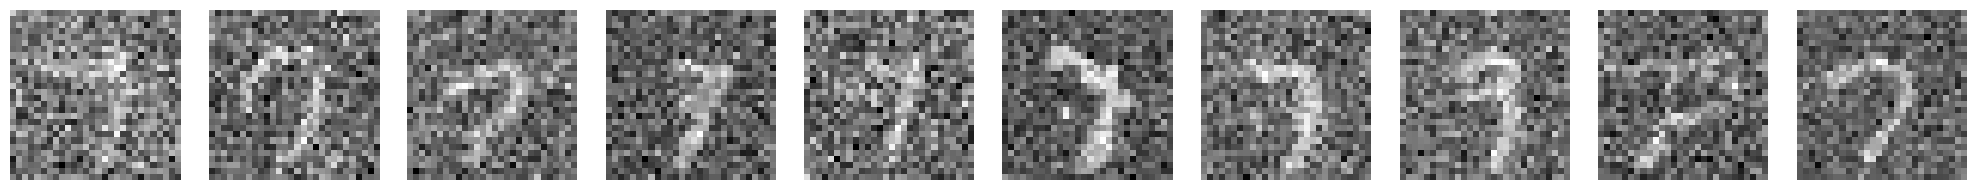

In [7]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def Denoising(model, label, img_size=(1, 28, 28), T=30, device="cpu"):
    model.eval()
    betas = torch.linspace(1e-4, 0.02, T, device=device)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)

    # pure noise
    x_t = torch.randn(1, *img_size, device=device)

    # Convert the label to a tensor
    label_tensor = torch.tensor([int(label)], device=device, dtype=torch.long)

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device, dtype=torch.long)

        eps_theta = model(x_t, label_tensor, t_tensor)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = betas[t]

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta
        )

        if t > 0:
            # variance term σ_t z
            alpha_bar_prev = alpha_bar[t-1] if t > 0 else torch.tensor(1.0, device=device)
            posterior_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            sigma_t = torch.sqrt(posterior_var)
            noise = torch.randn_like(x_t)
            x_t = mean + sigma_t * noise
        else:
            # at t=0, just take the mean
            x_t = mean

    return x_t


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Diffusion().to(device)
    try:
        model.load_state_dict(torch.load('diffusion_unet_conditional_model.pth', map_location=device), strict=False)
        print("Model weights loaded successfully.")
    except FileNotFoundError:
        print("Model weights file not found. Please train the model first.")
        exit()

    label = input("what no. do you want - ")

    print("Label - ", label)

    T_list = 10

    gen_images = []
    for T_val in range(T_list):
        gen_image = Denoising(model, label, img_size=(1, 28, 28), T=130, device= device)
        # denormalize the image for display
        gen_images.append(gen_image * 0.5 + 0.5)

    fig, axes = plt.subplots(1, T_list, figsize=(T_list*2, 2), dpi=100)
    for axis, img, t_val in zip(axes, gen_images, range(T_list)):
        axis.imshow(img.squeeze().cpu(), cmap="gray")
        # axis.set_title(f"T={t_val}")
        axis.set_xticks([])
        axis.set_yticks([])
        axis.axis('off')
    plt.tight_layout()
    plt.show()